## NBA Points per Minute Predictor - XGBoost Quantile
**- Owner:** Alex

**- Status:** Exploration only - not a production pipeline yet

**- Last Updated:** 10/3/26

### Question

**How accurately can we predict an NBA player's points per minute in their next game,
and can XGBoost beat a simple rolling average of recent points per minute and LightGBM?**

### Decision Criteria
**- Primary metric:** q50 pinball (points per minute). Lower is better.

**- Secondary metric:** 80% interval (q10–q90) and 90% interval (q05–q95) coverage near their targets

**- Serving threshold:** none yet — exploration only

**- Guardrail:** no quantile crossing; 2025-26 is scored once and never used to tune

### Data Contract
**- Data:** nba_api, rotowire, and basketball reference

**- Unit:** one row per player-game (`game_id`, `player_id`)

**- Features:** `PTS_FEATURES` from the points model. Pregame only. Game N minutes, game N points, and `predicted_minutes_oof` are excluded.

**- Label:** `min(pts / minutes, 6.0)` on rows with `minutes` > 0

**- Split:** chronological; train through 2024-25, hold out 2025-26


### Setup and Configurations


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def _repo_root() -> Path:
    starts = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        starts.append(Path(nb).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes.rolling import prior_ewm, prior_expanding, prior_shift
from src.features.points import add_points_features


In [3]:
# ── Prop-specific config (capped points per minute) ──────────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
RATE_CAP = 6.0
TARGET_COL = "pts_per_min"
ROLE_COL = "starting"
SEED = 42

QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Rate search already run in pts_nba_model. Pre-holdout pool only.
XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)
# Minutes lock, copied as a starting point. Retune on the rate before locking.
LGB_PARAMS = dict(
    objective="quantile",
    n_jobs=-1,
    random_state=42,
    verbose=-1,
    bagging_freq=1,
    early_stopping_rounds=50,
    n_estimators=1332,
    num_leaves=39,
    max_depth=8,
    learning_rate=0.010913251568080208,
    subsample=0.6164222829891212,
    colsample_bytree=0.6536603998011501,
    reg_alpha=0.004696562896252921,
    reg_lambda=0.11261493876779227,
    min_child_samples=30,
)

RATE_TIERS = {
    "<0.30": lambda a: a < 0.30,
    "0.30-0.50": lambda a: (a >= 0.30) & (a < 0.50),
    "0.50-0.70": lambda a: (a >= 0.50) & (a < 0.70),
    "0.70+": lambda a: a >= 0.70,
}

ARTIFACT_STEM = "pts_nba_model"

from models.shared.splits import prepare_splits
from models.shared.train import (
    evaluate_holdout,
    fit_quantile_lightgbm,
    run_timeseries_cv,
    run_walk_forward,
    tune_lgb_quantile,
)
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss
from models.shared.oos import capped_rate


### Data


In [4]:
s20 = pd.read_parquet(ROOT / "data/silver/nba/2019-20/regular_season/player_gamelogs.parquet")
s21 = pd.read_parquet(ROOT / "data/silver/nba/2020-21/regular_season/player_gamelogs.parquet")
s22 = pd.read_parquet(ROOT / "data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet(ROOT / "data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet(ROOT / "data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet(ROOT / "data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet(ROOT / "data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)
df.sample(5)


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting
23832,2025-26,1642364,Jamir Watkins,Jamir,1610612764,WAS,Washington Wizards,0022500029,2025-11-07T00:00:00,WAS vs. CLE,...,104.5,87.08,105,0.622,Regular Season,SG,241.0,13.5,13.5,0
7454,2025-26,1630592,Jalen Wilson,Jalen,1610612751,BKN,Brooklyn Nets,0022500859,2026-02-27T00:00:00,BKN @ BOS,...,93.0,77.50,93,0.681,Regular Season,PF,208.5,-16.5,16.5,0
13627,2019-20,203952,Andrew Wiggins,Andrew,1610612750,MIN,Minnesota Timberwolves,0021900411,2019-12-18T00:00:00,MIN vs. NOP,...,101.5,84.58,102,0.587,Regular Season,SF,230.0,-3.5,-3.5,1
1912,2023-24,201587,Nicolas Batum,Nicolas,1610612755,PHI,Philadelphia 76ers,0022301111,2024-04-04T00:00:00,PHI @ MIA,...,98.5,82.08,98,0.468,Regular Season,PF,211.5,-2.5,2.5,1
12080,2024-25,1631209,Isaiah Wong,Isaiah,1610612766,CHA,Charlotte Hornets,0022400637,2025-01-25T00:00:00,CHA vs. NOP,...,100.5,83.75,101,0.357,Regular Season,SG,230.5,1.5,1.5,0


In [5]:
# Data Quality Checks
print(f"Number of rows : {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of Unique Players: {df['player_id'].nunique()}")
print(f"Number of Unique Games: {df['game_id'].nunique()}")
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Missing points: {df['pts'].isna().sum()}")
print(f"Missing minutes: {df['minutes'].isna().sum()}")
print(f"Zero-minute rows: {int((df['minutes'] == 0).sum())}")
print(f"Median points: {df['pts'].median()}")
print(f"Mean points: {df['pts'].mean().round(3)}")
played = df.loc[df["minutes"] > 0, "pts"] / df.loc[df["minutes"] > 0, "minutes"]
print(f"Median points per minute (appearances): {played.median():.3f}")
print(f"Mean points per minute (appearances): {played.mean():.3f}")
print(f"Max raw points per minute: {played.max():.3f}")


Number of rows : 176738
Number of columns: 190
Number of Unique Players: 1172
Number of Unique Games: 8289
Total number of duplicates: 0
Missing points: 0
Missing minutes: 0
Zero-minute rows: 13
Median points: 9.0
Mean points: 10.629
Median points per minute (appearances): 0.409
Mean points per minute (appearances): 0.428
Max raw points per minute: 30.000


### Features


`PTS_FEATURES` is the trained contract. Game N minutes, game N points, and `predicted_minutes_oof` stay out.


In [6]:
# adds features to the dataset
df = add_points_features(df)


In [7]:
# selected features to use in the model
PTS_FEATURES = [
    "pts_per_min_10",
    "pts_per_min_20",
    "season_pts_per_min",
    "current_team_pts_per_min",
    "ppm_10_minus_season",
    "fta_per_min_10",
    "fg3a_per_min_10",
    "ts_agg_20",
    "usg_wmean_10",
    "player_fga_share_10",
    "min_mean_10",
    "starting",
    "implied_team_total",
    "team_spread_canonical",
    "expected_possessions",
    "opp_def_rating_mean_10",
    "season_appearances_prior",
    "current_team_rows_prior",
]
_EXCLUDED_FEATURES = {"minutes", "pts", "predicted_minutes_oof"}
leaked = _EXCLUDED_FEATURES.intersection(PTS_FEATURES)
if leaked:
    raise AssertionError(f"Game-N outcomes leaked into features: {sorted(leaked)}")
missing = [column for column in PTS_FEATURES if column not in df.columns]
if missing:
    raise KeyError(f"Rate features missing from the panel: {missing}")
print(f"Number of features: {len(PTS_FEATURES)}")
print(f"Number of nulls: {df[PTS_FEATURES].isna().sum().sum()}")


Number of features: 18
Number of nulls: 29676


### Train/validation/test design
**- Train:** 2019-10-22 → 2025-04-13 (2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2024-25). Each fold fits on its past dates. The 2025-26 fit uses the first 90% of this pool.

**- Validation:** Inside the train pool only. Optuna picks hyperparameters on a 3-fold TimeSeriesSplit by q50 pinball. Walk-forward then scores 4 non-overlapping blocks, each the next 10% of game dates after a 50% training window, stepping forward 10%. Those windows end 2024-11-25, 2024-12-31, 2025-02-01, and 2025-03-10. The first half of train dates, and dates after 2025-03-10, are never scored.

**- Test:** 2025-10-21 → 2026-04-12 (2025-26). Scored once, after features and hyperparameters are locked on the validation folds.

**- Split type:** Chronological. Walk-forward keeps every row from a game_date on one side. TimeSeriesSplit cuts by row index, so one slate can straddle a fold.

**- Embargo:** None. The next game date after the last training date is validation. The gap from 2025-04-13 to 2025-10-21 is the offseason, not a purge.

**- Important:** 2025-26 is not used to choose features, hyperparameters, or early-stopping rounds. Walk-forward still early-stops on the rows it scores. The holdout fit early-stops on the last 10% of the train pool and never puts 2025-26 in eval_set.


In [8]:
df = df.loc[df["minutes"] > 0].copy()
df = df.sort_values(
    ["game_date", "game_id", "player_id"], kind="mergesort"
).reset_index(drop=True)
df[TARGET_COL] = capped_rate(df["pts"], df["minutes"], cap=RATE_CAP)
# Naive baselines for the rate label. Not model features.
df["pts_per_min_lag_1"] = prior_shift(df, TARGET_COL, ["player_id"])
df["pts_per_min_ewm_hl_3"] = prior_ewm(df, TARGET_COL, ["player_id"], halflife=3)
df["season_pts_per_min_mean"] = prior_expanding(
    df, TARGET_COL, ["player_id", "season_year"], "mean"
)
print(f"After filtering appearances: {len(df):,} rows")
print(df[TARGET_COL].describe().round(3))

splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=PTS_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=[
        "minutes",
        "pts",
        "pts_per_min_lag_1",
        "season_pts_per_min_mean",
        "pts_per_min_ewm_hl_3",
    ],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]
print(f"Train pool (excl. {HOLDOUT_SEASON}) : {len(ppm_df):,} rows")
print(f"Holdout   ({HOLDOUT_SEASON})        : {len(ppm_holdout):,} rows")
print(
    f"Date range (train)   : {ppm_df['game_date'].min().date()} → "
    f"{ppm_df['game_date'].max().date()}"
)
print(
    f"Date range (holdout) : {ppm_holdout['game_date'].min().date()} → "
    f"{ppm_holdout['game_date'].max().date()}"
)


After filtering appearances: 176,710 rows
count    176710.000
mean          0.428
std           0.295
min           0.000
25%           0.229
50%           0.409
75%           0.597
max           6.000
Name: pts_per_min, dtype: float64
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


### EDA


Appearance rows: 176,710
Features with a null: 15 / 18
Rows with any null feature: 9,391 (5.3%)


,n_missing,pct_missing
implied_team_total,4706,2.66
team_spread_canonical,4197,2.38
season_pts_per_min,3936,2.23
ppm_10_minus_season,3936,2.23
current_team_pts_per_min,2624,1.48
ts_agg_20,1399,0.79
pts_per_min_10,1172,0.66
pts_per_min_20,1172,0.66
fta_per_min_10,1172,0.66
fg3a_per_min_10,1172,0.66


,implied_team_total,team_spread_canonical,season_pts_per_min,ppm_10_minus_season,current_team_pts_per_min,ts_agg_20,pts_per_min_10,pts_per_min_20,fta_per_min_10,fg3a_per_min_10,usg_wmean_10,player_fga_share_10,min_mean_10,expected_possessions,opp_def_rating_mean_10
season_year,,,,,,,,,,,,,,,
2019-20,7.7,7.7,2.4,2.4,2.6,2.7,2.4,2.4,2.4,2.4,2.4,2.4,2.4,1.5,1.4
2020-21,0.0,0.0,2.3,2.3,1.4,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.0
2021-22,4.1,2.3,2.3,2.3,1.6,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.0
2022-23,0.7,0.7,2.1,2.1,1.1,0.4,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.0,0.0
2023-24,3.9,3.9,2.2,2.2,1.3,0.5,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.0,0.0
2024-25,0.2,0.2,2.2,2.2,1.2,0.5,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.0,0.0
2025-26,2.4,2.3,2.2,2.2,1.3,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.0,0.0


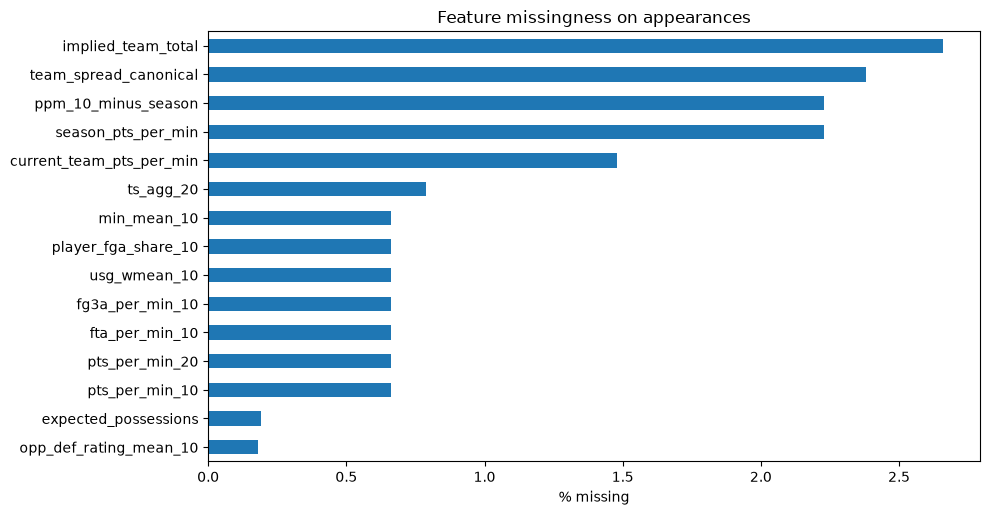

In [9]:
# Feature missingness

miss = pd.DataFrame({
    "n_missing": df[PTS_FEATURES].isna().sum(),
    "pct_missing": (df[PTS_FEATURES].isna().mean() * 100).round(2),
}).sort_values(["pct_missing", "n_missing"], ascending=False)

n_any = int(df[PTS_FEATURES].isna().any(axis=1).sum())
print(f"Appearance rows: {len(df):,}")
print(f"Features with a null: {int((miss['n_missing'] > 0).sum())} / {len(PTS_FEATURES)}")
print(f"Rows with any null feature: {n_any:,} ({n_any / len(df):.1%})")

sparse = miss.index[miss["n_missing"] > 0].tolist()
display(miss)
if sparse:
    season_miss_pct = (
        df[sparse]
        .isna()
        .groupby(df["season_year"], sort=True)
        .mean()
        .mul(100)
        .round(1)
    )
    display(season_miss_pct)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(sparse))))
    miss.loc[sparse, "pct_missing"].sort_values().plot.barh(ax=ax, color="C0")
    ax.set_xlabel("% missing")
    ax.set_title("Feature missingness on appearances")
    fig.tight_layout()
    plt.show()
else:
    print("Every selected feature is complete on this frame.")


n=176,710  min=0.00  p50=0.41  max=6.00
Tukey fence [-0.32, 1.15]  outside=2,397 (1.4%)
Rows at the 6 points-per-minute cap: 9


,season_year,game_date,player_name,pts_per_min,starting
8747,2019-20,2019-12-18,Ryan Broekhoff,6.0,0
17702,2019-20,2020-02-22,Jalen Brunson,6.0,1
75613,2022-23,2022-11-12,Dyson Daniels,6.0,0
79523,2022-23,2022-12-08,Keon Johnson,6.0,0
97266,2022-23,2023-04-09,Wendell Moore Jr.,6.0,0
100446,2023-24,2023-11-12,Brandin Podziemski,6.0,0
113557,2023-24,2024-02-06,Jordan Goodwin,6.0,0
114268,2023-24,2024-02-11,Orlando Robinson,6.0,0


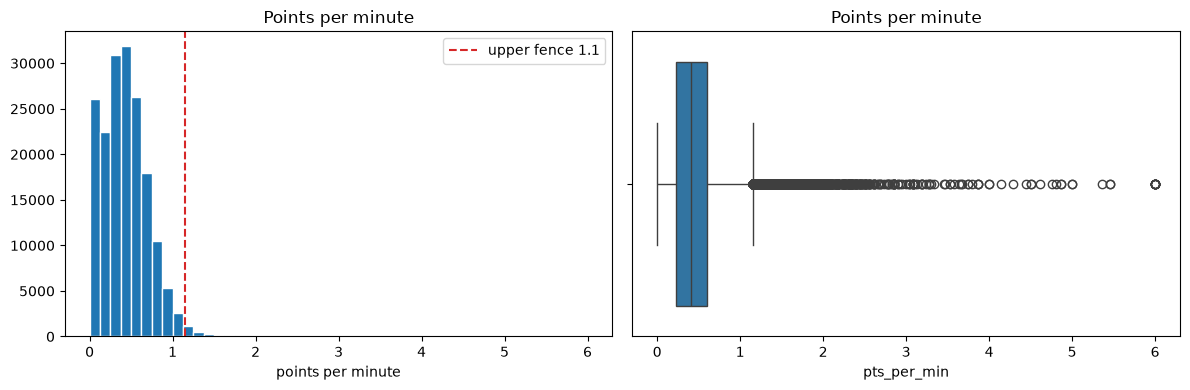

Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.


,feature,n,pct_outside,fence_low,fence_high,min,p50,max
0,ppm_10_minus_season,172774,5.47,-0.13,0.14,-2.17,0.00,0.97
1,current_team_rows_prior,176710,5.02,-130.50,273.50,0.00,56.00,501.00
2,ts_agg_20,175311,3.49,0.39,0.75,0.00,0.57,1.50
3,current_team_pts_per_min,174086,3.21,0.08,0.77,0.00,0.42,3.30
4,season_pts_per_min,172774,3.01,0.04,0.81,0.00,0.41,3.30
5,fta_per_min_10,175538,2.85,-0.07,0.23,0.00,0.07,1.43
6,pts_per_min_20,175538,2.28,0.05,0.81,0.00,0.42,3.30
7,pts_per_min_10,175538,1.98,0.02,0.84,0.00,0.42,3.30
8,usg_wmean_10,175538,1.41,0.03,0.33,0.00,0.18,1.00
9,expected_possessions,176367,0.99,94.62,104.83,92.90,99.71,111.50


In [10]:
# Outliers

rate = df[TARGET_COL]
q1, q3 = rate.quantile(0.25), rate.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_tukey = int(((rate < lo) | (rate > hi)).sum())
n_ot = int((rate >= RATE_CAP).sum())
print(
    f"n={len(rate):,}  min={rate.min():.2f}  "
    f"p50={rate.median():.2f}  max={rate.max():.2f}"
)
print(
    f"Tukey fence [{lo:.2f}, {hi:.2f}]  "
    f"outside={n_tukey:,} ({n_tukey / len(rate):.1%})"
)
print(f"Rows at the {RATE_CAP:g} points-per-minute cap: {n_ot:,}")

top_minutes = (
    df.nlargest(8, TARGET_COL)[
        ["season_year", "game_date", "player_name", TARGET_COL, "starting"]
    ]
    .assign(game_date=lambda frame: pd.to_datetime(frame["game_date"]).dt.date)
)
display(top_minutes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rate, bins=48, color="C0", edgecolor="white")
axes[0].axvline(hi, color="C3", ls="--", label=f"upper fence {hi:.1f}")
axes[0].set_title("Points per minute")
axes[0].set_xlabel("points per minute")
axes[0].legend()
sns.boxplot(x=rate, ax=axes[1], color="C0")
axes[1].set_title("Points per minute")
fig.tight_layout()
plt.show()

outlier_rows = []
for col in PTS_FEATURES:
    values = df[col].dropna()
    if values.nunique(dropna=True) <= 2:
        continue
    fq1, fq3 = values.quantile([0.25, 0.75])
    spread = float(fq3 - fq1)
    if spread <= 0:
        continue
    fence_lo = float(fq1 - 1.5 * spread)
    fence_hi = float(fq3 + 1.5 * spread)
    outside = (values < fence_lo) | (values > fence_hi)
    outlier_rows.append({
        "feature": col,
        "n": int(values.shape[0]),
        "pct_outside": round(100 * float(outside.mean()), 2),
        "fence_low": round(fence_lo, 2),
        "fence_high": round(fence_hi, 2),
        "min": round(float(values.min()), 2),
        "p50": round(float(values.median()), 2),
        "max": round(float(values.max()), 2),
    })

feature_outliers = (
    pd.DataFrame(outlier_rows)
    .sort_values("pct_outside", ascending=False)
    .reset_index(drop=True)
)
print("Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.")
display(feature_outliers)


In [11]:
# Coverage by Season

complete = ~df[PTS_FEATURES].isna().any(axis=1)
coverage = df.groupby("season_year", sort=True).agg(
    rows=("player_id", "size"),
    players=("player_id", "nunique"),
    games=("game_id", "nunique"),
    first_game=("game_date", "min"),
    last_game=("game_date", "max"),
)
coverage["first_game"] = pd.to_datetime(coverage["first_game"]).dt.date
coverage["last_game"] = pd.to_datetime(coverage["last_game"]).dt.date
coverage["pct_rows_complete"] = (
    complete.groupby(df["season_year"], sort=True).mean().mul(100).round(1)
)
coverage["mean_missing_features"] = (
    df[PTS_FEATURES]
    .isna()
    .sum(axis=1)
    .groupby(df["season_year"], sort=True)
    .mean()
    .round(2)
)
print(f"Seasons: {len(coverage)}  rows: {int(coverage['rows'].sum()):,}")
display(coverage)


Seasons: 7  rows: 176,710


,rows,players,games,first_game,last_game,pct_rows_complete,mean_missing_features
season_year,,,,,,,
2019-20,22387,529,1059,2019-10-22,2020-08-14,89.3,0.45
2020-21,23053,540,1080,2020-12-22,2021-05-16,97.2,0.10
2021-22,26035,605,1230,2021-10-19,2022-04-10,93.1,0.17
2022-23,25892,539,1230,2022-10-18,2023-04-09,96.9,0.09
2023-24,26393,572,1230,2023-10-24,2024-04-14,93.5,0.17
2024-25,26302,569,1230,2024-10-22,2025-04-13,97.2,0.09
2025-26,26648,582,1230,2025-10-21,2026-04-12,95.2,0.13


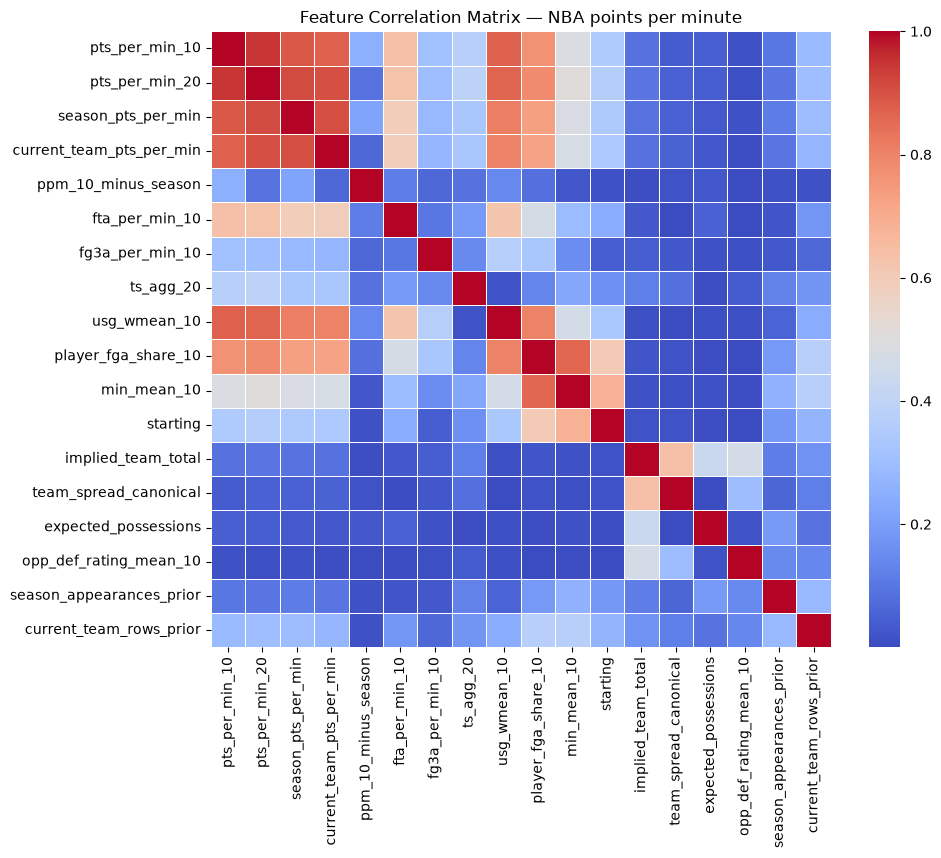

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [12]:
correlated_features = analyze_correlations(
    df, PTS_FEATURES, title="Feature Correlation Matrix — NBA points per minute"
)
correlated_features


### Models


In [13]:
# Hyperparameter tuning
# Leave commented if you don't want to retune the model

# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=50, n_splits=3)
# XGB_PARAMS = result["best_params"]

# lgb_result = tune_lgb_quantile(
#     ppm_df[PTS_FEATURES],
#     ppm_df[TARGET_COL],
#     n_trials=40,
#     n_splits=4,
#     seed=SEED,
# )
# LGB_PARAMS = lgb_result["best_params"]


In [14]:
# Model 1: XGBoost using time series cross validation and walk forward validation

tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit (XGBoost) ──────────────────────────

TSCV fold 1
  n=25010
  pinball  | q0.05=0.018  q0.10=0.033  q0.20=0.058  q0.30=0.076  q0.40=0.088  q0.50=0.093  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.031
  coverage | 80%=79.4% (target 80%)  90%=90.0% (target 90%)
  Starters   | n=11708 | pinball q50: 0.076 | 80% coverage: 80.4%
  Bench      | n=13302 | pinball q50: 0.109 | 80% coverage: 78.5%
  minute tiers by predicted q50
  <0.30      | n= 6228 | pinball q50: 0.104 | 80% coverage: 81.1%
  0.30-0.50  | n=13761 | pinball q50: 0.092 | 80% coverage: 78.6%
  0.50-0.70  | n= 4067 | pinball q50: 0.081 | 80% coverage: 79.1%
  0.70+      | n=  954 | pinball q50: 0.090 | 80% coverage: 80.3%

TSCV fold 2
  n=25010
  pinball  | q0.05=0.018  q0.10=0.034  q0.20=0.058  q0.30=0.076  q0.40=0.088  q0.50=0.093  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.030
  coverage | 80%=80.0% (target 80%)  90%=90.8% (target 90%)
  Starters   | n=11825 | pinbal

In [15]:
# Model 2: LightGBM using the same TimeSeriesSplit and walk-forward path

import importlib
import models.shared.train as train_mod

importlib.reload(train_mod)
run_timeseries_cv = train_mod.run_timeseries_cv
run_walk_forward = train_mod.run_walk_forward

tscv_results_lgb = run_timeseries_cv(
    X, y, ppm_df,
    lgb_params=LGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    quantiles=QUANTILES,
)
wf_lgb = run_walk_forward(
    X, y, ppm_df,
    lgb_params=LGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    quantiles=QUANTILES,
)

wf_results_lgb = wf_lgb["wf_results"]
models_last_lgb = wf_lgb["models_last"]
preds_last_lgb = wf_lgb["preds_last"]


── Phase 1: TimeSeriesSplit (LightGBM) ──────────────────────────


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


TSCV fold 1
  n=25010
  pinball  | q0.05=0.018  q0.10=0.033  q0.20=0.058  q0.30=0.076  q0.40=0.088  q0.50=0.094  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.031
  coverage | 80%=76.0% (target 80%)  90%=86.8% (target 90%)
  Starters   | n=11708 | pinball q50: 0.076 | 80% coverage: 79.6%
  Bench      | n=13302 | pinball q50: 0.109 | 80% coverage: 72.8%
  minute tiers by predicted q50
  <0.30      | n= 5841 | pinball q50: 0.104 | 80% coverage: 73.1%
  0.30-0.50  | n=14213 | pinball q50: 0.093 | 80% coverage: 76.7%
  0.50-0.70  | n= 4064 | pinball q50: 0.082 | 80% coverage: 77.5%
  0.70+      | n=  892 | pinball q50: 0.089 | 80% coverage: 77.8%


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


TSCV fold 2
  n=25010
  pinball  | q0.05=0.018  q0.10=0.034  q0.20=0.058  q0.30=0.076  q0.40=0.088  q0.50=0.093  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.030
  coverage | 80%=77.9% (target 80%)  90%=88.1% (target 90%)
  Starters   | n=11825 | pinball q50: 0.076 | 80% coverage: 80.0%
  Bench      | n=13185 | pinball q50: 0.109 | 80% coverage: 76.0%
  minute tiers by predicted q50
  <0.30      | n= 5897 | pinball q50: 0.105 | 80% coverage: 76.4%
  0.30-0.50  | n=13826 | pinball q50: 0.092 | 80% coverage: 78.2%
  0.50-0.70  | n= 4258 | pinball q50: 0.083 | 80% coverage: 78.9%
  0.70+      | n= 1029 | pinball q50: 0.089 | 80% coverage: 77.4%


...


WF fold 2  (2023-02-07 → 2023-12-05)
  n=14919
  pinball  | q0.05=0.018  q0.10=0.034  q0.20=0.059  q0.30=0.077  q0.40=0.088  q0.50=0.094  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.031
  coverage | 80%=78.1% (target 80%)  90%=88.4% (target 90%)
  Starters   | n= 7050 | pinball q50: 0.077 | 80% coverage: 79.9%
  Bench      | n= 7869 | pinball q50: 0.109 | 80% coverage: 76.5%
  minute tiers by predicted q50
  <0.30      | n= 3433 | pinball q50: 0.107 | 80% coverage: 75.0%
  0.30-0.50  | n= 7875 | pinball q50: 0.092 | 80% coverage: 78.7%
  0.50-0.70  | n= 2732 | pinball q50: 0.084 | 80% coverage: 79.8%
  0.70+      | n=  879 | pinball q50: 0.090 | 80% coverage: 79.2%


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


WF fold 3  (2023-12-05 → 2024-03-17)
  n=15346
  pinball  | q0.05=0.018  q0.10=0.034  q0.20=0.059  q0.30=0.078  q0.40=0.090  q0.50=0.096  q0.60=0.095  q0.70=0.088  q0.80=0.074  q0.90=0.050  q0.95=0.032
  coverage | 80%=78.0% (target 80%)  90%=88.2% (target 90%)
  Starters   | n= 7160 | pinball q50: 0.076 | 80% coverage: 80.3%
  Bench      | n= 8186 | pinball q50: 0.113 | 80% coverage: 76.1%
  minute tiers by predicted q50
  <0.30      | n= 3654 | pinball q50: 0.108 | 80% coverage: 76.6%
  0.30-0.50  | n= 7873 | pinball q50: 0.095 | 80% coverage: 78.0%
  0.50-0.70  | n= 2856 | pinball q50: 0.084 | 80% coverage: 79.7%
  0.70+      | n=  963 | pinball q50: 0.089 | 80% coverage: 79.2%


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is


WF fold 4  (2024-03-17 → 2025-01-02)
  n=15441
  pinball  | q0.05=0.018  q0.10=0.033  q0.20=0.058  q0.30=0.077  q0.40=0.089  q0.50=0.096  q0.60=0.096  q0.70=0.089  q0.80=0.075  q0.90=0.051  q0.95=0.032
  coverage | 80%=77.9% (target 80%)  90%=87.4% (target 90%)
  Starters   | n= 7170 | pinball q50: 0.078 | 80% coverage: 79.3%
  Bench      | n= 8271 | pinball q50: 0.111 | 80% coverage: 76.7%
  minute tiers by predicted q50
  <0.30      | n= 4194 | pinball q50: 0.111 | 80% coverage: 76.6%
  0.30-0.50  | n= 7861 | pinball q50: 0.092 | 80% coverage: 78.2%
  0.50-0.70  | n= 2776 | pinball q50: 0.085 | 80% coverage: 78.5%
  0.70+      | n=  610 | pinball q50: 0.085 | 80% coverage: 81.6%

────────────────────────────────────────────────────────────
Walk-Forward Summary (4/4 folds)
  Pinball q50 : 0.094 ± 0.001
  Coverage 80%: 78.3% ± 0.5%  (target 80%)

────────────────────────────────────────────────────────────
Per-fold pinball (q50) and 80% coverage:
  Fold                                

In [16]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))


,split,quantile,pinball
0,WF fold 4 (2024-03-17 → 2025-01-02),0.05,0.0182
1,WF fold 4 (2024-03-17 → 2025-01-02),0.10,0.0335
2,WF fold 4 (2024-03-17 → 2025-01-02),0.20,0.0583
3,WF fold 4 (2024-03-17 → 2025-01-02),0.30,0.0768
4,WF fold 4 (2024-03-17 → 2025-01-02),0.40,0.0895
5,WF fold 4 (2024-03-17 → 2025-01-02),0.50,0.0957
6,WF fold 4 (2024-03-17 → 2025-01-02),0.60,0.0957
7,WF fold 4 (2024-03-17 → 2025-01-02),0.70,0.0890
8,WF fold 4 (2024-03-17 → 2025-01-02),0.80,0.0747
9,WF fold 4 (2024-03-17 → 2025-01-02),0.90,0.0506


,split,interval,coverage,target
0,WF fold 4 (2024-03-17 → 2025-01-02),80%,0.7995,0.8
1,WF fold 4 (2024-03-17 → 2025-01-02),90%,0.9043,0.9


In [17]:
# Test model on holdout set

holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=PTS_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))


── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.019  q0.10=0.035  q0.20=0.060  q0.30=0.078  q0.40=0.090  q0.50=0.095  q0.60=0.095  q0.70=0.087  q0.80=0.073  q0.90=0.049  q0.95=0.031
  coverage | 80%=79.9% (target 80%)  90%=90.6% (target 90%)
  Starters   | n=12300 | pinball q50: 0.079 | 80% coverage: 78.9%
  Bench      | n=14348 | pinball q50: 0.109 | 80% coverage: 80.8%
  minute tiers by predicted q50
  <0.30      | n= 6093 | pinball q50: 0.108 | 80% coverage: 84.3%
  0.30-0.50  | n=14070 | pinball q50: 0.093 | 80% coverage: 78.4%
  0.50-0.70  | n= 5172 | pinball q50: 0.086 | 80% coverage: 78.9%
  0.70+      | n= 1313 | pinball q50: 0.089 | 80% coverage: 79.5%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 0.094
  Holdout pinball q50             : 0.095
  Pi

,split,quantile,pinball
0,2025-26 holdout,0.05,0.0188
1,2025-26 holdout,0.10,0.0345
2,2025-26 holdout,0.20,0.0597
3,2025-26 holdout,0.30,0.0779
4,2025-26 holdout,0.40,0.0898
5,2025-26 holdout,0.50,0.0952
6,2025-26 holdout,0.60,0.0946
7,2025-26 holdout,0.70,0.0875
8,2025-26 holdout,0.80,0.0734
9,2025-26 holdout,0.90,0.0494


,split,interval,coverage,target
0,2025-26 holdout,80%,0.7990,0.8
1,2025-26 holdout,90%,0.9062,0.9


In [18]:
# empirical quantile calibration

y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0396,-0.0104
1,0.10,0.10,0.0942,-0.0058
2,0.20,0.20,0.1967,-0.0033
3,0.30,0.30,0.2948,-0.0052
4,0.40,0.40,0.3927,-0.0073
5,0.50,0.50,0.4952,-0.0048
6,0.60,0.60,0.5955,-0.0045
7,0.70,0.70,0.6981,-0.0019
8,0.80,0.80,0.7974,-0.0026
9,0.90,0.90,0.8932,-0.0068


In [19]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 783 / 26,648 rows (2.9%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0005
1,q_0.10,q_0.20,0.0146
2,q_0.20,q_0.30,0.0126
3,q_0.30,q_0.40,0.0056
4,q_0.40,q_0.50,0.0008
5,q_0.50,q_0.60,0.0000
6,q_0.60,q_0.70,0.0000
7,q_0.70,q_0.80,0.0000
8,q_0.80,q_0.90,0.0000
9,q_0.90,q_0.95,0.0000


In [20]:
predicted = np.asarray(preds_ho["q_0.50"], dtype=float)
y_true = np.asarray(y_ho, dtype=float)
low_80 = np.asarray(preds_ho["q_0.10"], dtype=float)
high_80 = np.asarray(preds_ho["q_0.90"], dtype=float)
low_90 = np.asarray(preds_ho["q_0.05"], dtype=float)
high_90 = np.asarray(preds_ho["q_0.95"], dtype=float)
width_80 = high_80 - low_80
width_90 = high_90 - low_90

tier_rows = []
for name, fn in RATE_TIERS.items():
    mask = np.asarray(fn(predicted), dtype=bool)
    n = int(mask.sum())
    if n == 0:
        continue
    tier_rows.append({
        "tier": name,
        "n": n,
        "share": n / len(predicted),
        "pinball_q50": pinball_loss(y_true[mask], predicted[mask], 0.50),
        "empirical_q50": float(np.mean(y_true[mask] <= predicted[mask])),
        "coverage_80": interval_coverage(y_true[mask], low_80[mask], high_80[mask]),
        "coverage_90": interval_coverage(y_true[mask], low_90[mask], high_90[mask]),
        "mean_width_80": float(np.mean(width_80[mask])),
        "mean_width_90": float(np.mean(width_90[mask])),
    })
tier_report = pd.DataFrame(tier_rows)
print(f"{HOLDOUT_SEASON} holdout — rate tiers by predicted q50")
display(tier_report.round(4))


2025-26 holdout — rate tiers by predicted q50


,tier,n,share,pinball_q50,empirical_q50,coverage_80,coverage_90,mean_width_80,mean_width_90
0,<0.30,6093,0.2286,0.1082,0.4953,0.8426,0.9371,0.6418,0.8221
1,0.30-0.50,14070,0.5280,0.0935,0.4960,0.7842,0.8998,0.5869,0.7452
2,0.50-0.70,5172,0.1941,0.0862,0.4927,0.7889,0.8910,0.5481,0.7089
3,0.70+,1313,0.0493,0.0892,0.4958,0.7951,0.8919,0.5620,0.7393


In [21]:
# Model 2: LightGBM quantile regression

es_cutoff = int(len(ppm_df) * 0.90)
fit_df = ppm_df.iloc[:es_cutoff]
stop_df = ppm_df.iloc[es_cutoff:]
models_lgb, _ = fit_quantile_lightgbm(
    fit_df[PTS_FEATURES],
    fit_df[TARGET_COL],
    stop_df[PTS_FEATURES],
    stop_df[TARGET_COL],
    quantiles=QUANTILES,
    lgb_params=LGB_PARAMS,
)
X_lgb_ho = ppm_holdout[PTS_FEATURES]
y_lgb_ho = ppm_holdout[TARGET_COL].to_numpy(dtype=float)
preds_lgb = {key: model.predict(X_lgb_ho) for key, model in models_lgb.items()}

lgb_pinball, lgb_coverage = score_predictions(
    y_lgb_ho, preds_lgb, f"{HOLDOUT_SEASON} lightgbm"
)

cmp_pinball = (
    ho_pinball[["quantile", "pinball"]]
    .merge(
        lgb_pinball[["quantile", "pinball"]],
        on="quantile",
        suffixes=("_xgb", "_lgb"),
    )
)
cmp_pinball["xgb_minus_lgb"] = (
    cmp_pinball["pinball_xgb"] - cmp_pinball["pinball_lgb"]
)
cmp_coverage = (
    ho_coverage[["interval", "coverage", "target"]]
    .merge(
        lgb_coverage[["interval", "coverage"]],
        on="interval",
        suffixes=("_xgb", "_lgb"),
    )
)

print(
    f"{HOLDOUT_SEASON} holdout — LightGBM quantile vs XGBoost\n"
    f"  train rows {len(ppm_df):,} | fit rows {es_cutoff:,} | "
    f"early-stop rows {len(ppm_df) - es_cutoff:,} | holdout rows {len(y_lgb_ho):,}\n"
    "  xgb_minus_lgb < 0 means the XGBoost pinball is lower"
)
display(cmp_pinball.round(4))
display(cmp_coverage.round(4))


/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/Users/alexgonzalez/Documents/nba_quant/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is

2025-26 holdout — LightGBM quantile vs XGBoost
  train rows 150,062 | fit rows 135,055 | early-stop rows 15,007 | holdout rows 26,648
  xgb_minus_lgb < 0 means the XGBoost pinball is lower


,quantile,pinball_xgb,pinball_lgb,xgb_minus_lgb
0,0.05,0.0188,0.0188,0.0001
1,0.10,0.0345,0.0344,0.0001
2,0.20,0.0597,0.0596,0.0002
3,0.30,0.0779,0.0778,0.0001
4,0.40,0.0898,0.0897,0.0001
5,0.50,0.0952,0.0952,0.0001
6,0.60,0.0946,0.0945,0.0000
7,0.70,0.0875,0.0875,-0.0000
8,0.80,0.0734,0.0734,0.0000
9,0.90,0.0494,0.0494,0.0000


,interval,coverage_xgb,target,coverage_lgb
0,80%,0.7990,0.8,0.7799
1,90%,0.9062,0.9,0.8849


In [22]:
def interval_sharpness(y_true, preds):
    y_true = np.asarray(y_true, dtype=float)
    rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        width = (
            np.asarray(preds[high_key], dtype=float)
            - np.asarray(preds[low_key], dtype=float)
        )
        rows.append({
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
            "mean_width": float(np.mean(width)),
            "median_width": float(np.median(width)),
        })
    return pd.DataFrame(rows)

sharp_xgb = interval_sharpness(y_ho, preds_ho)
sharp_lgb = interval_sharpness(y_lgb_ho, preds_lgb)

cmp_sharpness = (
    sharp_xgb[["interval", "target", "coverage", "mean_width", "median_width"]]
    .merge(
        sharp_lgb[["interval", "coverage", "mean_width", "median_width"]],
        on="interval",
        suffixes=("_xgb", "_lgb"),
    )
)
cmp_sharpness["mean_width_xgb_minus_lgb"] = (
    cmp_sharpness["mean_width_xgb"] - cmp_sharpness["mean_width_lgb"]
)

print(
    f"{HOLDOUT_SEASON} holdout — interval sharpness (points per minute)\n"
    "  mean_width_xgb_minus_lgb < 0 means the XGBoost interval is narrower"
)
display(cmp_sharpness.round(4))


2025-26 holdout — interval sharpness (points per minute)
  mean_width_xgb_minus_lgb < 0 means the XGBoost interval is narrower


,interval,target,coverage_xgb,mean_width_xgb,median_width_xgb,coverage_lgb,mean_width_lgb,median_width_lgb,mean_width_xgb_minus_lgb
0,80%,0.8,0.7990,0.5907,0.5604,0.7799,0.5873,0.5540,0.0034
1,90%,0.9,0.9062,0.7554,0.7194,0.8849,0.7455,0.7095,0.0099


### Baseline


In [23]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

XGB_NAME = "Quantile XGBoost"
LGB_NAME = "Quantile LightGBM"

y_all = np.asarray(y_ho, dtype=float)
model_quantiles = {
    XGB_NAME: {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()},
    LGB_NAME: {key: np.asarray(pred, dtype=float) for key, pred in preds_lgb.items()},
}
for name, qmap in model_quantiles.items():
    if len(next(iter(qmap.values()))) != len(y_all):
        raise ValueError(f"{name} predictions do not match the holdout length")
alpha_of = {
    key: float(str(key).split("_", 1)[1]) for key in model_quantiles[XGB_NAME]
}
ordered_keys = sorted(model_quantiles[XGB_NAME], key=alpha_of.get)
baselines = {
    "Last-game rate": ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float),
    "Season-to-date rate": ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float),
    "EWMA rate": ppm_holdout["pts_per_min_ewm_hl_3"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all)
for qmap in model_quantiles.values():
    paired &= np.isfinite(qmap["q_0.50"])
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
xgb_q50_name = f"{XGB_NAME} q50"
lgb_q50_name = f"{LGB_NAME} q50"
paired_preds = {
    xgb_q50_name: model_quantiles[XGB_NAME]["q_0.50"][paired],
    lgb_q50_name: model_quantiles[LGB_NAME]["q_0.50"][paired],
}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game rate",
    "Season-to-date rate",
    "EWMA rate",
    lgb_q50_name,
    xgb_q50_name,
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae[xgb_q50_name]
delta_table = pd.DataFrame([
    {
        "comparison": f"XGBoost q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == xgb_q50_name, "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "pts_per_min_lag_1"),
        ("season_average", "season_pts_per_min_mean"),
        ("ewma", "pts_per_min_ewm_hl_3"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"XGBoost q50 pinball {pinball_loss(y_paired, paired_preds[xgb_q50_name], 0.50):.4f}; "
    f"LightGBM q50 pinball {pinball_loss(y_paired, paired_preds[lgb_q50_name], 0.50):.4f}. "
    "Each equals half that model's q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means XGBoost q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward MAE is XGBoost only: 2 × q50 pinball on every validation row. "
    "LightGBM is scored on the holdout, not inside these folds. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

def interval_stats(y, qmap, low, high):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in qmap or high_key not in qmap:
        return {"cov": np.nan, "width_mean": np.nan, "width_median": np.nan}
    width = qmap[high_key] - qmap[low_key]
    return {
        "cov": interval_coverage(y, qmap[low_key], qmap[high_key]),
        "width_mean": float(np.mean(width)),
        "width_median": float(np.median(width)),
    }

def distribution_row(name, y, qmap):
    band_80 = interval_stats(y, qmap, 0.10, 0.90)
    band_90 = interval_stats(y, qmap, 0.05, 0.95)
    keys = sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
    grid = np.column_stack([qmap[key] for key in keys])
    if grid.shape[1] < 2:
        crossed = 0.0
    else:
        crossed = float(np.mean(np.any(np.diff(grid, axis=1) < 0, axis=1)))
    return {
        "model": name,
        "cov_80": band_80["cov"],
        "width_80_mean": band_80["width_mean"],
        "width_80_median": band_80["width_median"],
        "cov_90": band_90["cov"],
        "width_90_mean": band_90["width_mean"],
        "width_90_median": band_90["width_median"],
        "wis": float(np.mean(wis_values(y, qmap))),
        "quantile_crossing": crossed,
    }

print("\n2. Distribution quality")
wis_knots = [
    f"{low}–{high}"
    for _alpha, low, high in WIS_INTERVALS
    if low in model_quantiles[XGB_NAME] and high in model_quantiles[XGB_NAME]
]
print(
    "WIS uses the trained knots only: "
    + (", ".join(wis_knots) if wis_knots else "median only")
    + ", plus the q50 term."
)
distribution = pd.DataFrame([
    distribution_row(name, y_all, qmap) for name, qmap in model_quantiles.items()
])
display(distribution.round(4))
xgb_dist = distribution.loc[distribution["model"] == XGB_NAME].iloc[0]
lgb_dist = distribution.loc[distribution["model"] == LGB_NAME].iloc[0]
print(
    "XGBoost minus LightGBM WIS "
    f"{xgb_dist['wis'] - lgb_dist['wis']:+.4f}. "
    "Negative is the better distribution score."
)
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "model": name,
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= qmap[key])),
        "difference": float(np.mean(y_all <= qmap[key]) - alpha_of[key]),
    }
    for name, qmap in model_quantiles.items()
    for key in sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
])
display(calibration.round(4))

def subgroup_rows_for(group, mask):
    rows = []
    base = np.asarray(mask, dtype=bool) & np.isfinite(y_all)
    for name, qmap in model_quantiles.items():
        use = base & np.isfinite(qmap["q_0.50"])
        n = int(use.sum())
        if n == 0:
            continue
        y = y_all[use]
        part = {key: values[use] for key, values in qmap.items()}
        error = y - part["q_0.50"]
        band_80 = interval_stats(y, part, 0.10, 0.90)
        band_90 = interval_stats(y, part, 0.05, 0.95)
        rows.append({
            "model": name,
            "group": group,
            "n": n,
            "mae": float(np.mean(np.abs(error))),
            "bias": float(np.mean(error)),
            "wis": float(np.mean(wis_values(y, part))),
            "cov_80": band_80["cov"],
            "width_80_mean": band_80["width_mean"],
            "width_80_median": band_80["width_median"],
            "cov_90": band_90["cov"],
            "width_90_mean": band_90["width_mean"],
            "width_90_median": band_90["width_median"],
        })
    return rows

print("\n4. Pregame-defined subgroups")
print("Rate tiers use XGBoost predicted q50, so both models are scored on the same games.")
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
xgb_q50 = model_quantiles[XGB_NAME]["q_0.50"]
subgroup_rows = []
subgroup_rows.extend(subgroup_rows_for("Confirmed starter", starting == 1))
subgroup_rows.extend(subgroup_rows_for("Bench", starting == 0))
for name, fn in RATE_TIERS.items():
    subgroup_rows.extend(subgroup_rows_for(f"Predicted q50 {name}", fn(xgb_q50)))
for month in sorted(months.unique()):
    subgroup_rows.extend(subgroup_rows_for(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame(subgroup_rows)
display(subgroup_table.round(3))

print("\n5. Tail failures")
tail_rows = []
for name, qmap in model_quantiles.items():
    absolute_error = np.abs(y_all - qmap["q_0.50"])
    for cutoff in (0.15, 0.25, 0.40):
        tail_rows.append({
            "model": name,
            "threshold": f">{cutoff:g} pts/min",
            "rate": float(np.mean(absolute_error > cutoff)),
            "n": int(np.sum(absolute_error > cutoff)),
        })
tail_table = pd.DataFrame(tail_rows)
display(tail_table.round(4))

xgb_cal = calibration.loc[calibration["model"] == XGB_NAME]
lgb_cal = calibration.loc[calibration["model"] == LGB_NAME]
best_delta = delta_table.loc[
    delta_table["comparison"] == f"XGBoost q50 − {best_name}"
].iloc[0]
lgb_delta = delta_table.loc[
    delta_table["comparison"] == f"XGBoost q50 − {lgb_q50_name}"
].iloc[0]
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
for label, frame in ((XGB_NAME, xgb_cal), (LGB_NAME, lgb_cal)):
    q50_rate = float(frame.loc[frame["quantile"] == "q50", "observed"].iloc[0])
    max_gap = float(frame["difference"].abs().max())
    print(f"  {label} q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
    print(f"  {label} largest |quantile gap| {max_gap:.1%}")
print(
    f"  XGBoost q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(
    f"  XGBoost q50 vs LightGBM q50: delta MAE {lgb_delta['delta_mae']:+.3f} "
    f"[{lgb_delta['ci_low']:+.3f}, {lgb_delta['ci_high']:+.3f}]"
)
print(
    f"  WIS {xgb_dist['wis']:.3f} (XGBoost) vs {lgb_dist['wis']:.3f} (LightGBM) "
    f"vs best baseline CRPS/MAE {best_mae:.3f}"
)
print(
    "  walk-forward folds with XGBoost MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(
    f"  raw quantile crossing "
    f"{xgb_dist['quantile_crossing']:.2%} (XGBoost), "
    f"{lgb_dist['quantile_crossing']:.2%} (LightGBM)"
)


1. Point accuracy versus baselines
Identical holdout rows: 26,066  |  dropped 582 with a missing baseline  |  2,000 date-clustered resamples
Mean bias is actual minus predicted. XGBoost q50 pinball 0.0946; LightGBM q50 pinball 0.0945. Each equals half that model's q50 MAE.


,model,mae,median_ae,mean_bias
0,Last-game rate,0.258,0.201,0.002
1,Season-to-date rate,0.197,0.157,0.007
2,EWMA rate,0.199,0.160,0.002
3,Quantile LightGBM q50,0.189,0.150,0.027
4,Quantile XGBoost q50,0.189,0.151,0.027


Paired MAE difference, clustered by game date. Negative means XGBoost q50 is lower.


,comparison,delta_mae,ci_low,ci_high
0,XGBoost q50 − Last-game rate,-0.069,-0.071,-0.066
1,XGBoost q50 − Season-to-date rate,-0.008,-0.010,-0.007
2,XGBoost q50 − EWMA rate,-0.010,-0.011,-0.008
3,XGBoost q50 − Quantile LightGBM q50,0.000,-0.000,0.000


Walk-forward MAE is XGBoost only: 2 × q50 pinball on every validation row. LightGBM is scored on the holdout, not inside these folds. Baseline MAE drops rows with no prior.


...


4. Pregame-defined subgroups
Rate tiers use XGBoost predicted q50, so both models are scored on the same games.


,model,group,n,mae,bias,wis,cov_80,width_80_mean,width_80_median,cov_90,width_90_mean,width_90_median
0,Quantile XGBoost,Confirmed starter,12300,0.158,0.013,0.109,0.789,0.500,0.498,0.893,0.651,0.647
1,Quantile LightGBM,Confirmed starter,12300,0.158,0.015,0.109,0.789,0.497,0.497,0.892,0.646,0.643
2,Quantile XGBoost,Bench,14348,0.218,0.041,0.147,0.808,0.669,0.645,0.917,0.845,0.809
3,Quantile LightGBM,Bench,14348,0.218,0.039,0.147,0.772,0.664,0.642,0.879,0.830,0.800
4,Quantile XGBoost,Predicted q50 <0.30,6093,0.216,0.064,0.144,0.843,0.642,0.613,0.937,0.822,0.767
5,Quantile LightGBM,Predicted q50 <0.30,6093,0.216,0.060,0.144,0.774,0.637,0.605,0.880,0.803,0.744
6,Quantile XGBoost,Predicted q50 0.30-0.50,14070,0.187,0.020,0.128,0.784,0.587,0.568,0.900,0.745,0.728
7,Quantile LightGBM,Predicted q50 0.30-0.50,14070,0.187,0.021,0.128,0.778,0.585,0.561,0.885,0.738,0.718
8,Quantile XGBoost,Predicted q50 0.50-0.70,5172,0.172,0.014,0.119,0.789,0.548,0.529,0.891,0.709,0.684
9,Quantile LightGBM,Predicted q50 0.50-0.70,5172,0.173,0.015,0.119,0.790,0.545,0.525,0.888,0.702,0.678



5. Tail failures


,model,threshold,rate,n
0,Quantile XGBoost,>0.15 pts/min,0.5040,13431
1,Quantile XGBoost,>0.25 pts/min,0.2756,7344
2,Quantile XGBoost,>0.4 pts/min,0.0807,2151
3,Quantile LightGBM,>0.15 pts/min,0.5026,13392
4,Quantile LightGBM,>0.25 pts/min,0.2765,7369
5,Quantile LightGBM,>0.4 pts/min,0.0803,2141



Checks from this frame
  Quantile XGBoost q50 observed rate 49.5%  (target about 48–52%)
  Quantile XGBoost largest |quantile gap| 1.0%
  Quantile LightGBM q50 observed rate 49.5%  (target about 48–52%)
  Quantile LightGBM largest |quantile gap| 1.2%
  XGBoost q50 vs Season-to-date rate: delta MAE -0.008 [-0.010, -0.007]
  XGBoost q50 vs LightGBM q50: delta MAE +0.000 [-0.000, +0.000]
  WIS 0.130 (XGBoost) vs 0.129 (LightGBM) vs best baseline CRPS/MAE 0.197
  walk-forward folds with XGBoost MAE below the best baseline: 4 / 4
  raw quantile crossing 2.94% (XGBoost), 13.14% (LightGBM)


### Features Analysis


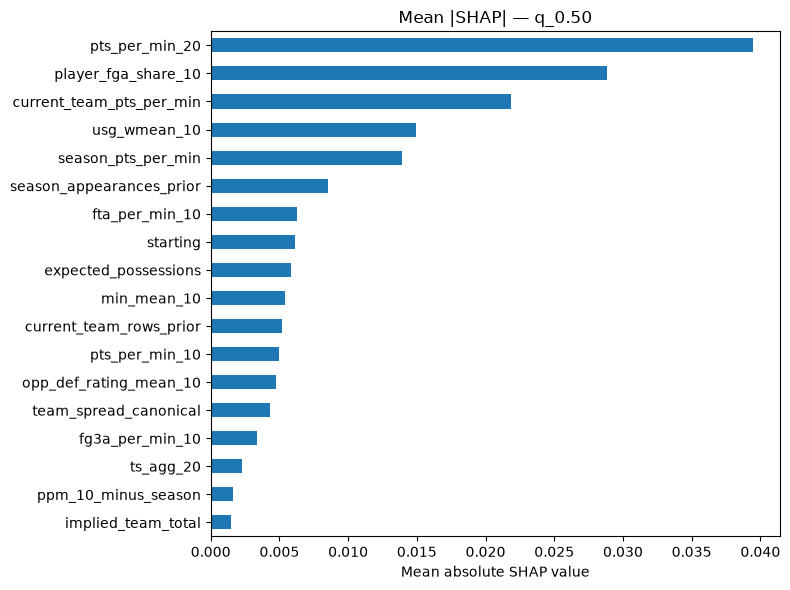

In [24]:
import shap

model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=PTS_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [25]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                     feature  importance      std  p_value  significant
1             pts_per_min_20     0.00341  0.00014      0.0         True
2        player_fga_share_10     0.00267  0.00013      0.0         True
3   current_team_pts_per_min     0.00132  0.00009      0.0         True
4               usg_wmean_10     0.00071  0.00008      0.0         True
5         season_pts_per_min     0.00064  0.00007      0.0         True
6                min_mean_10     0.00035  0.00003      0.0         True
7                   starting     0.00020  0.00005      0.0         True
8    current_team_rows_prior     0.00020  0.00002      0.0         True
9   season_appearances_prior     0.00018  0.00005      0.0         True
10     team_spread_canonical     0.00016  0.00004      0.0         True
11    opp_def_rating_mean_10     0.00014  0.00003      0.0         True
12            fta_per_min_10     0.00014  0.00003      

In [26]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X.loc[train_mask_last]
X_va_last = X.loc[val_mask_last]
y_tr_last = ppm_df.loc[train_mask_last, TARGET_COL]
y_va_last = ppm_df.loc[val_mask_last, TARGET_COL]

ablation_df = run_feature_ablation(
    PTS_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline pinball q50 (all features): 0.0957
                     feature  ablated_pinball  delta_pinball
1   current_team_pts_per_min           0.0959         0.0002
2    current_team_rows_prior           0.0958         0.0001
3                min_mean_10           0.0957         0.0001
4     opp_def_rating_mean_10           0.0958         0.0001
5             pts_per_min_20           0.0958         0.0001
6   season_appearances_prior           0.0957         0.0000
7       expected_possessions           0.0957         0.0000
8      team_spread_canonical           0.0957         0.0000
9         implied_team_total           0.0957        -0.0000
10                  starting           0.0957         0.0000
11            pts_per_min_10           0.0957        -0.0000
12              usg_wmean_10           0.0957         0.0000
13                 ts_agg_20           0.0957        -0.0000
14           fg3a_per_min_10           0.0957         0.0000
15            fta_per_min_10           0.

In [27]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": PTS_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                     feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1             pts_per_min_20       0.039455          1          1          0.00341              0.00014  8.569525e-42          0.0001   1.000000   1.000000   1.000000   True
2        player_fga_share_10       0.028810          2          2          0.00267              0.00013  9.208258e-40         -0.0000   0.730187   0.782991   0.756589  False
3   current_team_pts_per_min       0.021873          3          3          0.00132              0.00009  7.038791e-36          0.0002   0.554379   0.387097   0.470738   True
4               usg_wmean_10       0.014917          4          4          0.00071              0.00008  7.628739e-30          0.0000   0.378064   0.208211   0.293138  False
5         season_pts_per_min       0.013885          5          5          0.00064              0.00007  2.347419e-30         -0.0

### Slice Analysis


In [28]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} \u2192 {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October\u2013February": dates < "2026-03-01",
    "March 1\u201314": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15\u201331": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.3f} pts/min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["pts_per_min_ewm_hl_3"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (pts_per_min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, TARGET_COL].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if pts_per_min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_pts_per_min_mean is missing. "
    "If pts_per_min_lag_1 is missing, do not use the tree. Use the training-pool rate quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,October–February,19417,0.189,0.026,0.497,0.803,0.590,0.128
1,March 1–14,2364,0.190,0.022,0.509,0.799,0.588,0.130
2,March 15–31,2806,0.194,0.028,0.494,0.783,0.590,0.132
3,April regular season,2061,0.203,0.050,0.465,0.783,0.603,0.137


Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the regular season. It is not a postseason effect, and the model has not been tested on playoff games.

2. Starter and bench mean bias versus median calibration


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,Confirmed starter,12300,0.158,0.013,0.496,0.789,0.500,0.109
1,Bench,14348,0.218,0.041,0.495,0.808,0.669,0.147


  Confirmed starter: bias +0.013 pts/min, P(actual <= q50) 49.6%. q50 is near 50%, so the mean bias is skew around a calibrated median.
  Bench: bias +0.041 pts/min, P(actual <= q50) 49.5%. q50 is near 50%, so the mean bias is skew around a calibrated median.

3. Monotone rearrangement
Crossing before 2.94% of rows; after rearrangement 0.00%.


,quantile,mean_abs_shift,share_changed
0,q_0.05,0.0000,0.0068
1,q_0.10,0.0001,0.0211
2,q_0.20,0.0001,0.0262
3,q_0.30,0.0001,0.0144
4,q_0.40,0.0001,0.0068
5,q_0.50,0.0000,0.0013
6,q_0.60,0.0000,0.0001
7,q_0.70,0.0000,0.0000
8,q_0.80,0.0000,0.0000
9,q_0.90,0.0000,0.0000


Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.

4. Cold-start and missing-baseline rows
Missing any baseline: 582 | no prior game (pts_per_min_lag_1 missing): 104 | season opener with history: 478


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,"Season opener, model",478,0.237,0.066,0.502,0.774,0.662,0.163
1,"No prior game, model",104,0.300,0.163,0.452,0.817,0.795,0.201
2,"No prior game, role fallback",104,0.310,0.013,0.615,0.817,0.727,0.210
3,"Any missing baseline, model",582,0.249,0.083,0.493,0.782,0.686,0.170


Live fallback: if pts_per_min_lag_1 exists, predict with the quantile model and then sort that row into increasing quantile order, even when season_pts_per_min_mean is missing. If pts_per_min_lag_1 is missing, do not use the tree. Use the training-pool rate quantiles for the confirmed role (starter or bench). preds_ho_live applies that rule.


### Error Analysis


In [32]:
# Holdout misses. Score, fouls, and plus/minus are post-game context.
# They explain a miss; they were not inputs to the model.
# pts is already on the holdout frame, so the context merge leaves it alone.
ctx = (
    df[[
        "game_id", "player_id", "team_abbreviation", "matchup", "wl",
        "pf", "pfd", "plus_minus", "team_pts", "opp_pts",
        "abs_spread",
    ]]
    .drop_duplicates(["game_id", "player_id"])
)
team_minutes = (
    df.groupby(["game_id", "team_abbreviation"], as_index=False)["minutes"]
    .sum()
    .rename(columns={"minutes": "team_minutes"})
)

miss = ppm_holdout.reset_index(drop=True).copy()
miss["q10"] = np.asarray(preds_ho["q_0.10"], dtype=float)
miss["q50"] = np.asarray(preds_ho["q_0.50"], dtype=float)
miss["q90"] = np.asarray(preds_ho["q_0.90"], dtype=float)
miss["error"] = miss[TARGET_COL] - miss["q50"]
miss["abs_error"] = miss["error"].abs()
miss = miss.merge(ctx, on=["game_id", "player_id"], how="left")
miss = miss.merge(team_minutes, on=["game_id", "team_abbreviation"], how="left")
miss["game_date"] = pd.to_datetime(miss["game_date"]).dt.date
miss["score"] = (
    miss["team_pts"].round().astype("Int64").astype("string")
    + "-"
    + miss["opp_pts"].round().astype("Int64").astype("string")
)
miss["margin"] = miss["team_pts"] - miss["opp_pts"]
miss["ot"] = miss["team_minutes"] >= 260
miss["band"] = (
    miss["q10"].round().astype("Int64").astype("string")
    + "–"
    + miss["q90"].round().astype("Int64").astype("string")
)

sat_early = miss["error"] <= -0.20
played_more = miss["error"] >= 0.20
blowout = miss["margin"].abs() >= 15
outside_80 = (miss[TARGET_COL] < miss["q10"]) | (miss[TARGET_COL] > miss["q90"])
miss["hint"] = np.select(
    [
        (miss["pf"] >= 6) & sat_early,
        (miss["pf"] >= 5) & sat_early,
        blowout & sat_early & (miss["starting"] == 1),
        blowout & played_more & (miss["starting"] == 0),
        miss["ot"] & played_more,
        (miss["starting"] == 0) & (miss["pts_per_min_lag_1"] >= 0.50) & (miss["error"] <= -0.25),
        (miss["starting"] == 1) & (miss["pts_per_min_lag_1"].fillna(0) < 0.35) & (miss["error"] >= 0.25),
        outside_80,
    ],
    [
        "fouled out",
        "foul trouble",
        "blowout rest",
        "garbage time",
        "overtime",
        "unexpected bench",
        "unexpected start",
        "outside 10–90",
    ],
    default="",
)

show = [
    "game_date", "player_name", "matchup", "score", "wl",
    TARGET_COL, "minutes", "pts", "q50", "error", "band", "pf", "pfd",
    "starting", "plus_minus", "margin",
    "pts_per_min_lag_1", "season_pts_per_min_mean", "abs_spread", "ot", "hint",
]
labels = {
    "game_date": "date",
    "player_name": "player",
    "matchup": "game",
    TARGET_COL: "actual_rate",
    "minutes": "minutes",
    "pts": "pts",
    "q50": "pred_q50",
    "error": "actual − q50",
    "band": "q10–q90",
    "pf": "fouls",
    "pfd": "fouls_drawn",
    "plus_minus": "+/-",
    "pts_per_min_lag_1": "last_game_rate",
    "season_pts_per_min_mean": "season_rate",
    "abs_spread": "pregame_|spread|",
}

def show_misses(frame, title):
    view = frame[show].rename(columns=labels).round(1)
    print(title)
    display(view)

way_off = miss["abs_error"] >= 0.25
print(
    f"{HOLDOUT_SEASON} holdout: {int(way_off.sum()):,} / {len(miss):,} rows "
    f"missed by 0.25+ points per minute ({way_off.mean():.1%}). "
    f"Median |error| {miss['abs_error'].median():.1f}."
)
print("actual − q50 > 0 means the points-per-minute rate was above the median prediction.")

show_misses(
    miss.nsmallest(20, "error"),
    "\nScored much less per minute than q50",
)
show_misses(
    miss.nlargest(20, "error"),
    "\nScored much more per minute than q50",
)

biggest = pd.concat(
    [miss.nsmallest(20, "error"), miss.nlargest(20, "error")],
    ignore_index=True,
)
print("\nHints on those 40 misses")
print(biggest["hint"].replace("", "unlabeled").value_counts().to_string())

rotation = miss["q50"] >= 0.45
off_players = (
    miss.loc[rotation & (miss["abs_error"] >= 0.25)]
    .sort_values("abs_error", ascending=False)
    .groupby(["game_id", "team_abbreviation"])
    .apply(
        lambda g: ", ".join(
            f"{row.player_name} ({row.minutes:.0f} min, {row.error:+.2f}, {int(row.pf)} PF)"
            for row in g.itertuples()
        ),
        include_groups=False,
    )
    .rename("players_off_by_0.25")
    .reset_index()
)
games = (
    miss.loc[rotation]
    .groupby(["game_id", "game_date", "team_abbreviation", "matchup", "score", "wl"], as_index=False)
    .agg(
        n_rotation=("player_id", "size"),
        n_off_025=("abs_error", lambda s: int((s >= 0.25).sum())),
        mean_abs_error=("abs_error", "mean"),
        margin=("margin", "mean"),
        ot=("ot", "max"),
    )
    .merge(off_players, on=["game_id", "team_abbreviation"], how="left")
    .sort_values(["n_off_025", "mean_abs_error"], ascending=False)
)
print("\nTeam-games where the most players (predicted q50 ≥ 0.45) missed by 0.25+ points per minute")
display(
    games.head(15)[
        [
            "game_date", "matchup", "score", "wl", "margin", "ot",
            "n_rotation", "n_off_025", "mean_abs_error", "players_off_by_0.25",
        ]
    ].rename(columns={"game_date": "date", "matchup": "game"}).round(1)
)


2025-26 holdout: 7,344 / 26,648 rows missed by 0.25+ points per minute (27.6%). Median |error| 0.2.
actual − q50 > 0 means the points-per-minute rate was above the median prediction.

Scored much less per minute than q50


,date,player,game,score,wl,actual_rate,minutes,pts,pred_q50,actual − q50,...,fouls,fouls_drawn,starting,+/-,margin,last_game_rate,season_rate,pregame_|spread|,ot,hint
2507,2025-11-05,Cam Thomas,BKN @ IND,112-103,W,0.0,5.6,0,0.8,-0.8,...,0,0,1,4,9,0.7,0.8,6.5,False,outside 10–90
25877,2026-04-08,Jalen Green,PHX vs. DAL,112-107,W,0.0,3.8,0,0.7,-0.7,...,0,0,1,-1,5,0.5,0.7,12.5,False,outside 10–90
18511,2026-02-22,Deni Avdija,POR @ PHX,92-77,W,0.0,1.0,0,0.7,-0.7,...,0,0,1,0,15,0.5,0.7,3.5,False,blowout rest
11266,2026-01-03,Alperen Sengun,HOU @ DAL,104-110,L,0.0,1.1,0,0.6,-0.6,...,0,0,1,0,-6,0.6,0.6,8.0,False,outside 10–90
23753,2026-03-27,Donovan Mitchell,CLE vs. MIA,149-128,W,0.2,30.6,6,0.8,-0.6,...,2,3,1,14,21,0.8,0.8,5.5,False,blowout rest
10430,2025-12-29,Coby White,CHI vs. MIN,101-136,L,0.0,6.6,0,0.6,-0.6,...,0,0,1,1,-35,0.6,0.7,6.5,False,blowout rest
6418,2025-11-30,Keyonte George,UTA vs. HOU,101-129,L,0.0,19.1,0,0.6,-0.6,...,1,2,1,-27,-28,0.9,0.7,11.5,False,blowout rest
23248,2026-03-23,De'Anthony Melton,GSW @ DAL,137-131,W,0.0,22.5,0,0.6,-0.6,...,3,0,1,-1,6,0.9,0.6,2.5,True,outside 10–90
9121,2025-12-21,Karl-Anthony Towns,NYK vs. MIA,132-125,W,0.1,28.8,2,0.7,-0.6,...,4,2,1,-1,7,0.6,0.7,7.0,False,outside 10–90
22043,2026-03-16,Brandon Williams,DAL @ NOP,111-129,L,0.0,5.2,0,0.6,-0.6,...,0,1,0,-16,-18,0.5,0.6,8.5,False,unexpected bench



Scored much more per minute than q50


,date,player,game,score,wl,actual_rate,minutes,pts,pred_q50,actual − q50,...,fouls,fouls_drawn,starting,+/-,margin,last_game_rate,season_rate,pregame_|spread|,ot,hint
5525,2025-11-23,Taylor Hendricks,UTA vs. LAL,106-108,L,4.9,0.6,3,0.3,4.6,...,0,0,0,0,-2,0.1,0.2,9.0,False,outside 10–90
1166,2025-10-27,Olivier-Maxence Prosper,MEM @ GSW,118-131,L,3.6,1.1,4,0.3,3.2,...,0,1,0,4,-13,0.0,0.4,8.0,False,outside 10–90
12766,2026-01-12,Bronny James,LAL @ SAC,112-124,L,3.2,1.9,6,0.0,3.1,...,0,0,0,4,-12,0.0,0.2,9.5,False,outside 10–90
24668,2026-04-01,Caleb Houstan,ATL @ ORL,130-101,W,3.2,2.8,9,0.1,3.1,...,2,0,0,6,29,0.9,0.3,2.5,False,garbage time
8777,2025-12-19,Keshad Johnson,MIA @ BOS,116-129,L,3.3,0.9,3,0.3,3.0,...,0,0,0,6,-13,0.3,0.3,7.5,False,outside 10–90
20292,2026-03-05,Micah Peavy,NOP @ SAC,133-123,W,3.1,0.6,2,0.2,2.8,...,0,1,0,0,10,0.0,0.3,7.0,False,outside 10–90
1824,2025-11-01,Johnny Juzang,MIN @ CHA,122-105,W,3.1,1.0,3,0.3,2.8,...,0,0,0,0,17,0.0,0.2,4.5,False,garbage time
9239,2025-12-22,Kam Jones,IND @ BOS,95-103,L,2.9,0.7,2,0.2,2.7,...,0,0,0,2,-8,NaN,NaN,11.5,False,outside 10–90
21189,2026-03-11,Alijah Martin,TOR @ NOP,111-122,L,2.9,1.4,4,0.2,2.7,...,0,1,0,6,-11,0.6,0.3,1.0,False,outside 10–90
22048,2026-03-16,Jordan Hawkins,NOP vs. DAL,129-111,W,2.9,1.8,5,0.3,2.6,...,0,1,0,3,18,0.0,0.3,8.5,False,garbage time



Hints on those 40 misses
hint
outside 10–90       18
garbage time         9
blowout rest         8
unexpected bench     4
fouled out           1

Team-games where the most players (predicted q50 ≥ 0.45) missed by 0.25+ points per minute


,date,game,score,wl,margin,ot,n_rotation,n_off_025,mean_abs_error,players_off_by_0.25
2120,2026-03-27,IND vs. LAC,113-114,L,-1.0,False,7,6,0.4,"Jarace Walker (4 min, +0.68, 0 PF), Pascal Sia..."
2359,2026-04-12,DET @ IND,133-121,W,12.0,False,6,5,0.4,"Paul Reed (22 min, +0.64, 1 PF), Tobias Harris..."
1414,2026-02-01,DEN vs. OKC,111-121,L,-10.0,False,5,5,0.3,"Jonas Valanciunas (13 min, +0.47, 3 PF), Tim H..."
1492,2026-02-07,UTA @ ORL,117-120,L,-3.0,False,6,5,0.3,"Brice Sensabaugh (23 min, -0.40, 0 PF), Jusuf ..."
998,2026-01-05,DET vs. NYK,121-90,W,31.0,False,4,4,0.5,"Marcus Sasser (5 min, +1.13, 1 PF), Tolu Smith..."
722,2025-12-07,OKC @ UTA,131-101,W,30.0,False,4,4,0.4,"Chet Holmgren (23 min, +0.49, 2 PF), Aaron Wig..."
306,2025-11-02,SAS @ PHX,118-130,L,-12.0,False,5,4,0.4,"Dylan Harper (11 min, +0.56, 0 PF), Victor Wem..."
2241,2026-04-03,DAL vs. ORL,127-138,L,-11.0,False,6,4,0.4,"Cooper Flagg (34 min, +0.82, 3 PF), Khris Midd..."
2362,2026-04-12,MIA vs. ATL,143-117,W,26.0,False,5,4,0.4,"Jaime Jaquez Jr. (26 min, +0.47, 0 PF), Norman..."
1890,2026-03-11,DEN vs. HOU,129-93,W,36.0,False,5,4,0.4,"Aaron Gordon (22 min, -0.57, 0 PF), Jonas Vala..."


### Save Exploratory Artifact


In [31]:
from datetime import datetime, timezone

def _iso_date(value):
    return pd.Timestamp(value).date().isoformat()

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "status": "exploratory",
    "model_name": "quantile_xgboost",
    "artifact_stem": ARTIFACT_STEM,
    "features": list(PTS_FEATURES),
    "label": TARGET_COL,
    "label_rule": "min(pts / minutes, 6.0), minutes > 0",
    "quantiles": list(QUANTILES),
    "point_forecast": 0.50,
    "interval": [0.10, 0.90],
    "params": {
        key: XGB_PARAMS[key]
        for key in (
            "objective",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
            "min_child_weight",
            "early_stopping_rounds",
            "random_state",
        )
    },
    "seed": SEED,
    "train_range": [
        _iso_date(ppm_df["game_date"].min()),
        _iso_date(ppm_df["game_date"].max()),
    ],
    "holdout_season": HOLDOUT_SEASON,
    "holdout_range": [
        _iso_date(ppm_holdout["game_date"].min()),
        _iso_date(ppm_holdout["game_date"].max()),
    ],
    "primary_metric": "q50 pinball",
    "test_metrics": {
        "n": ho_metrics["n"],
        "pinball_q50": ho_metrics["pinball"],
        "coverage_80": ho_metrics.get("coverage_80pct"),
        "coverage_90": ho_metrics.get("coverage_90pct"),
        "walk_forward_pinball_q50": float(
            np.mean([row["pinball"] for row in wf_results])
        ),
    },
}
display(metadata)


{'created_at': '2026-10-03T10:34:50.740492+00:00',
 'status': 'exploratory',
 'model_name': 'quantile_xgboost',
 'artifact_stem': 'pts_nba_model',
 'features': ['pts_per_min_10',
  'pts_per_min_20',
  'season_pts_per_min',
  'current_team_pts_per_min',
  'ppm_10_minus_season',
  'fta_per_min_10',
  'fg3a_per_min_10',
  'ts_agg_20',
  'usg_wmean_10',
  'player_fga_share_10',
  'min_mean_10',
  'starting',
  'implied_team_total',
  'team_spread_canonical',
  'expected_possessions',
  'opp_def_rating_mean_10',
  'season_appearances_prior',
  'current_team_rows_prior'],
 'label': 'pts_per_min',
 'label_rule': 'min(pts / minutes, 6.0), minutes > 0',
 'quantiles': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
 'point_forecast': 0.5,
 'interval': [0.1, 0.9],
 'params': {'objective': 'reg:quantileerror',
  'n_estimators': 1695,
  'max_depth': 3,
  'learning_rate': 0.052852647946832816,
  'subsample': 0.5916232263322159,
  'colsample_bytree': 0.6284413523882679,
  'reg_alpha': 0.02

In [ ]:
import importlib
import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
save_model_bundle = artifact_mod.save_model_bundle
load_model_bundle = artifact_mod.load_model_bundle

save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=PTS_FEATURES,
    artifact_stem=ARTIFACT_STEM,
    metadata=metadata,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


### Conclusion
**- Selected Model:** Quantile XGBoost (`reg:quantileerror`) at all 11 levels, 0.05 through 0.95. Params are the rate search from `pts_nba_model` (depth 3, 1,695 trees). Bundle stem `pts_nba_model`. LightGBM uses the minutes lock as a starting point until it is retuned on this rate.

**- Primary test result:** Fill from the 2025-26 holdout cells after this notebook is run. Score q50 pinball, 80% and 90% coverage, WIS on the 11 knots, and adjacent-pair crossing. Compare XGBoost with LightGBM and with the last-game, season-to-date, and EWMA rate baselines on the paired rows.

**- Operating point:** None for serving. The point forecast is q50. The uncertainty band is q10–q90. Sort the 11 knots before a probability is read.

**- Label:** `min(pts / minutes, 6.0)` on appearances. Zeros stay out.
